In [1]:
import pandas as pd
import torch as th

plastchem_mol_fp = "/home/luke/fragnnet/data/proc/plastchem/mol_df.pkl"
nist20_mol_fp = "/home/luke/fragnnet/data/proc/nist20/mol_df.pkl"
nist20_spec_fp = "/home/luke/fragnnet/data/proc/nist20/spec_df.pkl"

plastchem_mol_df = pd.read_pickle(plastchem_mol_fp)
nist20_mol_df = pd.read_pickle(nist20_mol_fp)
nist20_spec_df = pd.read_pickle(nist20_spec_fp)

pred_fp = "/home/luke/fragnnet/data/inference/fragnnet_d3_195/predictions.parquet"

pred_df = pd.read_parquet(pred_fp)

In [2]:
plastchem_mol_df

,smiles,mol,mol_id,inchikey_s,scaffold,formula,inchi,mw,exact_mw,num_atoms,num_bonds,charge,single_mol,num_radicals
0,BrBr,<rdkit.Chem.rdchem.Mol object at 0x75b4b06a5210>,0,GDTBXPJZTBHREO,,Br2,InChI=1S/Br2/c1-2,159.808,157.836674,2,1,0,True,0
1,BrC(Br)=C(Br)c1ccccc1,<rdkit.Chem.rdchem.Mol object at 0x75b4b06a52b0>,1,JVPKLOPETWVKQD,c1ccccc1,C8H5Br3,InChI=1S/C8H5Br3/c9-7(8(10)11)6-4-2-1-3-5-6/h1-5H,340.840,337.794136,11,11,0,True,0
2,BrC(Br)=Cc1ccccc1,<rdkit.Chem.rdchem.Mol object at 0x75b4b06a5350>,2,CYLVUSZHVURAOY,c1ccccc1,C8H6Br2,InChI=1S/C8H6Br2/c9-8(10)6-7-4-2-1-3-5-7/h1-6H,261.944,259.883624,10,10,0,True,0
3,BrC(Br)Br,<rdkit.Chem.rdchem.Mol object at 0x75b4b01b0d10>,3,DIKBFYAXUHHXCS,,CHBr3,InChI=1S/CHBr3/c2-1(3)4/h1H,252.731,249.762836,4,3,0,True,0
4,BrC1(Br)CCCCCCCCCC(Br)(Br)C1(Br)Br,<rdkit.Chem.rdchem.Mol object at 0x75b4ae559990>,4,SHRRVNVEOIKVSG,C1CCCCCCCCCCC1,C12H18Br6,InChI=1S/C12H18Br6/c13-10(14)8-6-4-2-1-3-5-7-9...,641.700,635.650873,18,18,0,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9803,c1csc(C2=S=C(c3cccs3)c3nsnc32)c1,<rdkit.Chem.rdchem.Mol object at 0x75b4acdb0450>,9803,KXASLJJPAUTMIH,c1csc(C2=S=C(c3cccs3)c3nsnc32)c1,C12H6N2S4,InChI=1S/C12H6N2S4/c1-3-7(15-5-1)11-9-10(14-18...,306.462,305.941382,18,21,0,True,0
9804,c1nc(N2CCNCC2)nc(N2CCOCC2)n1,<rdkit.Chem.rdchem.Mol object at 0x75b4acdb04a0>,9804,AVOSVDRFHAWQCC,c1nc(N2CCNCC2)nc(N2CCOCC2)n1,C11H18N6O,InChI=1S/C11H18N6O/c1-3-16(4-2-12-1)10-13-9-14...,250.306,250.154209,18,20,0,True,0
9805,c1nc[nH]n1,<rdkit.Chem.rdchem.Mol object at 0x75b4acdb04f0>,9805,NSPMIYGKQJPBQR,c1nc[nH]n1,C2H3N3,"InChI=1S/C2H3N3/c1-3-2-5-4-1/h1-2H,(H,3,4,5)",69.067,69.032697,5,5,0,True,0
9806,c1scc2c1Cc1cscc1-2,<rdkit.Chem.rdchem.Mol object at 0x75b4acdb0540>,9806,HHSONWXYOAPAQZ,c1scc2c1Cc1cscc1-2,C9H6S2,InChI=1S/C9H6S2/c1-6-2-10-4-8(6)9-5-11-3-7(1)9...,178.281,177.991092,11,13,0,True,0


In [3]:
plastchem = plastchem_mol_df[['mol_id', 'smiles', 'inchikey_s', 'mol', 'scaffold', 'formula']]
plastchem_pred_join = plastchem.merge(pred_df, on='mol_id', how='left', validate='one_to_many')
plastchem_pred_join.rename(columns={'mol_id':'plastchem_mol_id'}, inplace=True)
plastchem_pred_join = plastchem_pred_join.drop(columns=['dset_spec_id', 'input_peaks'])
plastchem_pred_join

,plastchem_mol_id,smiles,inchikey_s,mol,scaffold,formula,group_id,spec_id,prec_type,inst_type,frag_mode,spec_type,ion_mode,dset,ace,prec_mz,pred_mzs,pred_ints
0,0,BrBr,GDTBXPJZTBHREO,<rdkit.Chem.rdchem.Mol object at 0x75b4b06a5210>,,Br2,0.0,0.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,158.843951,[160.84190368652344],[1.0]
1,1,BrC(Br)=C(Br)c1ccccc1,JVPKLOPETWVKQD,<rdkit.Chem.rdchem.Mol object at 0x75b4b06a52b0>,c1ccccc1,C8H5Br3,1.0,3.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,338.801413,"[184.84190368652344, 104.93344116210938, 185.8...","[6.9508073465840425e-06, 0.0002458884264342487..."
2,2,BrC(Br)=Cc1ccccc1,CYLVUSZHVURAOY,<rdkit.Chem.rdchem.Mol object at 0x75b4b06a5350>,c1ccccc1,C8H6Br2,2.0,6.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,260.890901,"[104.93344116210938, 27.022926330566406, 105.9...","[0.0003664105897769332, 2.040552089965786e-06,..."
3,3,BrC(Br)Br,DIKBFYAXUHHXCS,<rdkit.Chem.rdchem.Mol object at 0x75b4b01b0d10>,,CHBr3,3.0,9.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,250.770113,"[252.76806640625, 80.93344116210938]","[0.9998470544815063, 0.00015293045726139098]"
4,4,BrC1(Br)CCCCCCCCCC(Br)(Br)C1(Br)Br,SHRRVNVEOIKVSG,<rdkit.Chem.rdchem.Mol object at 0x75b4ae559990>,C1CCCCCCCCCCC1,C12H18Br6,4.0,12.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,636.658150,"[529.673095703125, 610.5894165039062, 530.6809...","[3.0911130579625024e-06, 2.168172386518563e-06..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9803,9803,c1csc(C2=S=C(c3cccs3)c3nsnc32)c1,KXASLJJPAUTMIH,<rdkit.Chem.rdchem.Mol object at 0x75b4acdb0450>,c1csc(C2=S=C(c3cccs3)c3nsnc32)c1,C12H6N2S4,9803.0,29409.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,306.948659,"[245.93746948242188, 246.94528198242188, 278.9...","[4.80210064779385e-06, 0.00022747012553736567,..."
9804,9804,c1nc(N2CCNCC2)nc(N2CCOCC2)n1,AVOSVDRFHAWQCC,<rdkit.Chem.rdchem.Mol object at 0x75b4acdb04a0>,c1nc(N2CCNCC2)nc(N2CCOCC2)n1,C11H18N6O,9804.0,29412.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,251.161486,"[218.1036376953125, 219.11146545410156, 217.11...","[3.1993084121495485e-05, 2.2873149646329693e-0..."
9805,9805,c1nc[nH]n1,NSPMIYGKQJPBQR,<rdkit.Chem.rdchem.Mol object at 0x75b4acdb04f0>,c1nc[nH]n1,C2H3N3,9805.0,29415.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,70.039974,"[68.02432250976562, 55.02907180786133, 69.0321...","[4.765759877045639e-05, 0.0006390911294147372,..."
9806,9806,c1scc2c1Cc1cscc1-2,HHSONWXYOAPAQZ,<rdkit.Chem.rdchem.Mol object at 0x75b4acdb0540>,c1scc2c1Cc1cscc1-2,C9H6S2,9806.0,29418.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,178.998369,"[57.9871711730957, 27.022926330566406, 58.9949...","[0.0050027635879814625, 2.4412827315245522e-06..."


In [4]:
nist20_mol_lookup = nist20_mol_df[['mol_id', 'smiles', 'inchikey_s']].copy()
nist20_mol_lookup.rename(columns={'mol_id': 'nist20_mol_id'}, inplace=True)
result = plastchem_pred_join.merge(nist20_mol_lookup, on=['smiles', 'inchikey_s'], how='inner')
result.rename(columns={'spec_id': 'plastchem_spec_id',
                       'prec_type': 'pred_prec_type',
                       'inst_type':'pred_inst_type',
                       'frag_mode': 'pred_frag_mode',
                       'spec_type': 'pred_spec_type',
                       'ion_mode': 'pred_ion_mode',
                       'dset': 'pred_dset',
                       'ace': 'pred_ace',
                       'prec_mz': 'pred_prec_mz',
                       'group_id': 'pred_group_id'
                       }, inplace=True)
result

,plastchem_mol_id,smiles,inchikey_s,mol,scaffold,formula,pred_group_id,plastchem_spec_id,pred_prec_type,pred_inst_type,pred_frag_mode,pred_spec_type,pred_ion_mode,pred_dset,pred_ace,pred_prec_mz,pred_mzs,pred_ints,nist20_mol_id
0,299,C#CC(C)(C)NC(=O)c1cc(Cl)cc(Cl)c1,PHNUZKMIPFFYSO,<rdkit.Chem.rdchem.Mol object at 0x75b4ae5c1e90>,c1ccccc1,C12H11Cl2NO,299.0,897.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,256.029046,"[215.02630615234375, 231.02122497558594, 180.0...","[1.7365919120493345e-06, 4.5687525016546715e-0...",162
1,305,C#CC1(O)CCC2C3CC=C4CC(=O)CCC4C3C(=C)CC21CC,BOMXWTHINLWJIE,<rdkit.Chem.rdchem.Mol object at 0x75b4ae5c2070>,C=C1CC2CCCC2C2CC=C3CC(=O)CCC3C12,C22H28O2,305.0,915.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,325.216207,"[131.0855255126953, 147.0804443359375, 132.093...","[0.02342192642390728, 0.01723371259868145, 0.0...",175
2,306,C#CC1(O)CCC2C3CC=C4CC(=O)CCC4C3CCC21C,QGQUHXSBTSDAML,<rdkit.Chem.rdchem.Mol object at 0x75b4ae5c20c0>,O=C1CCC2C(=CCC3C4CCCC4CCC23)C1,C20H26O2,306.0,918.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,299.200557,"[131.0855255126953, 147.0804443359375, 132.093...","[0.027450477704405785, 0.00650313775986433, 0....",176
3,333,C#Cc1ccc(N)cc1,JXYITCJMBRETQX,<rdkit.Chem.rdchem.Mol object at 0x75b4ae5c2930>,c1ccccc1,C8H7N,333.0,999.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,118.065126,"[40.01817321777344, 27.022926330566406, 41.025...","[3.6656606994256435e-07, 3.7324167578844936e-0...",261
4,350,C(=NC1CCCCC1)=NC1CCCCC1,QOSSAOTZNIDXMA,<rdkit.Chem.rdchem.Mol object at 0x75b4ae5c2e80>,C(=NC1CCCCC1)=NC1CCCCC1,C13H22N2,350.0,1050.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,207.185575,"[161.10733032226562, 162.1151580810547, 163.12...","[4.302845013626211e-07, 6.166992534417659e-07,...",271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1580,9791,c1ccc2sc(SSc3nc4ccccc4s3)nc2c1,AFZSMODLJJCVPP,<rdkit.Chem.rdchem.Mol object at 0x75b4acdb0090>,c1ccc2sc(SSc3nc4ccccc4s3)nc2c1,C14H8N2S4,9791.0,29373.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,332.964309,"[277.9095153808594, 246.94528198242188, 278.91...","[3.131940573553038e-08, 2.5172749928970006e-07...",34950
1581,9793,c1ccc2scnc2c1,IOJUPLGTWVMSFF,<rdkit.Chem.rdchem.Mol object at 0x75b4acdb0130>,c1ccc2scnc2c1,C7H5NS,9793.0,29379.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,136.021547,"[40.01817321777344, 57.9871711730957, 27.02292...","[9.999991945619513e-10, 0.00033202202757820487...",34951
1582,9796,c1ccncc1,JUJWROOIHBZHMG,<rdkit.Chem.rdchem.Mol object at 0x75b4acdb0220>,c1ccncc1,C5H5N,9796.0,29388.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,80.049476,"[40.01817321777344, 27.022926330566406, 41.025...","[2.0645936729124514e-06, 2.985036735481117e-05...",34956
1583,9799,c1cnc2c(c1)ccc1cccnc12,DGEZNRSVGBDHLK,<rdkit.Chem.rdchem.Mol object at 0x75b4acdb0310>,c1cnc2c(c1)ccc1cccnc12,C12H8N2,9799.0,29397.0,[M+H]+,FT,HCD,MS2,P,inference,20.0,181.076025,"[137.0260009765625, 151.02908325195312, 138.03...","[1.0048663170891814e-05, 4.170200099906651e-06...",34971


In [5]:
nist20_spec_lookup = nist20_spec_df[['spec_id', 'mol_id', 'group_id', 'prec_mz', 'prec_type', 'inst_type', 'ace', 'nce', 'dset', 'peaks']].copy()
nist20_spec_lookup.rename(columns={'mol_id': 'nist20_mol_id'}, inplace=True)
nist20_spec_lookup

,spec_id,nist20_mol_id,group_id,prec_mz,prec_type,inst_type,ace,nce,dset,peaks
0,0,10998,0,1467.0061,[M+NH4]+,QTOF,8.0,NaN,nist20_hr,"[(45.96, 46.35), (597.48, 51.85), (598.5, 41.3..."
1,1,10998,0,1467.0061,[M+NH4]+,QTOF,10.0,NaN,nist20_hr,"[(597.5, 50.95), (599.5, 683.32), (1449.98, 99..."
2,2,10998,0,1467.0061,[M+NH4]+,QTOF,14.0,NaN,nist20_hr,"[(537.39, 55.94), (599.5, 999.0), (600.51, 42...."
3,3,10998,0,1467.0061,[M+NH4]+,QTOF,16.0,NaN,nist20_hr,"[(597.46, 41.86), (598.5, 45.15), (599.51, 999..."
4,4,10998,0,1467.0061,[M+NH4]+,QTOF,20.0,NaN,nist20_hr,"[(598.49, 47.85), (599.5, 999.0), (600.5, 85.5..."
...,...,...,...,...,...,...,...,...,...,...
1148067,1155605,8926,214092,506.3318,[M+H]+,FT,NaN,50.0,mona23,"[(56.0502, 37.264882), (57.0706, 38.137391), (..."
1148068,1155606,8926,214092,506.3318,[M+H]+,FT,NaN,35.0,mona23,"[(56.0502, 8.156297), (57.0706, 10.644887), (6..."
1148069,1155607,8926,214092,506.3318,[M+H]+,FT,NaN,30.0,mona23,"[(56.0502, 4.315988), (57.0706, 5.02635), (60...."
1148070,1155608,8926,214092,506.3318,[M+H]+,FT,NaN,20.0,mona23,"[(276.2686, 3.505299), (294.2792, 24.68621), (..."


In [6]:
mapped_result = result.merge(nist20_spec_lookup, on='nist20_mol_id', how='inner')
# filter out rows without matching metadata
a = len(mapped_result)
print(f'> {a} rows after merge')
mapped_result = mapped_result.loc[mapped_result['inst_type'] == mapped_result['pred_inst_type']]
b = len(mapped_result)
print(f'> removed {a - b} rows without matching inst type')
mapped_result = mapped_result.loc[mapped_result['prec_type'] == mapped_result['pred_prec_type']]
c = len(mapped_result)
print(f'> removed {b - c} rows without matching adduct type')

# filter down to row where either ace or nce are within 10 of the pred ace.
# TODO: flag this bc i have no idea what nce and ace are.
mapped_result = mapped_result.loc[(abs(mapped_result['pred_ace'] - mapped_result['ace']) <= 10) |
                                  (abs(mapped_result['pred_ace'] - mapped_result['nce']) <= 10)]
d = len(mapped_result)
print(f'> removed {c - d} rows outside of ce tolerance range')

> 50993 rows after merge
> removed 14009 rows without matching inst type
> removed 22571 rows without matching adduct type
> removed 7994 rows outside of ce tolerance range


In [7]:
mapped_result

,plastchem_mol_id,smiles,inchikey_s,mol,scaffold,formula,pred_group_id,plastchem_spec_id,pred_prec_type,pred_inst_type,...,nist20_mol_id,spec_id,group_id,prec_mz,prec_type,inst_type,ace,nce,dset,peaks
0,299,C#CC(C)(C)NC(=O)c1cc(Cl)cc(Cl)c1,PHNUZKMIPFFYSO,<rdkit.Chem.rdchem.Mol object at 0x75b4ae5c1e90>,c1ccccc1,C12H11Cl2NO,299.0,897.0,[M+H]+,FT,...,162,312414,48762,256.029,[M+H]+,FT,6.0,10.0,nist20_hr,"[(67.0542, 2.2), (172.9554, 10.69), (189.9823,..."
1,299,C#CC(C)(C)NC(=O)c1cc(Cl)cc(Cl)c1,PHNUZKMIPFFYSO,<rdkit.Chem.rdchem.Mol object at 0x75b4ae5c1e90>,c1ccccc1,C12H11Cl2NO,299.0,897.0,[M+H]+,FT,...,162,312415,48762,256.029,[M+H]+,FT,7.0,15.0,nist20_hr,"[(67.0541, 2.8), (85.0648, 1.0), (172.9556, 15..."
2,299,C#CC(C)(C)NC(=O)c1cc(Cl)cc(Cl)c1,PHNUZKMIPFFYSO,<rdkit.Chem.rdchem.Mol object at 0x75b4ae5c1e90>,c1ccccc1,C12H11Cl2NO,299.0,897.0,[M+H]+,FT,...,162,312416,48762,256.029,[M+H]+,FT,9.0,20.0,nist20_hr,"[(65.0385, 1.0), (67.054, 7.09), (85.0648, 2.0..."
3,299,C#CC(C)(C)NC(=O)c1cc(Cl)cc(Cl)c1,PHNUZKMIPFFYSO,<rdkit.Chem.rdchem.Mol object at 0x75b4ae5c1e90>,c1ccccc1,C12H11Cl2NO,299.0,897.0,[M+H]+,FT,...,162,312417,48762,256.029,[M+H]+,FT,10.0,20.0,nist20_hr,"[(65.0385, 2.2), (67.054, 12.39), (85.0646, 2...."
4,299,C#CC(C)(C)NC(=O)c1cc(Cl)cc(Cl)c1,PHNUZKMIPFFYSO,<rdkit.Chem.rdchem.Mol object at 0x75b4ae5c1e90>,c1ccccc1,C12H11Cl2NO,299.0,897.0,[M+H]+,FT,...,162,312418,48762,256.029,[M+H]+,FT,11.0,20.0,nist20_hr,"[(65.0385, 2.9), (67.0541, 19.58), (85.0647, 4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50957,9793,c1ccc2scnc2c1,IOJUPLGTWVMSFF,<rdkit.Chem.rdchem.Mol object at 0x75b4acdb0130>,c1ccc2scnc2c1,C7H5NS,9793.0,29379.0,[M+H]+,FT,...,34951,1128393,183888,136.0215,[M+H]+,FT,NaN,15.0,mona23,"[(136.0216, 100.0)]"
50979,9799,c1cnc2c(c1)ccc1cccnc12,DGEZNRSVGBDHLK,<rdkit.Chem.rdchem.Mol object at 0x75b4acdb0310>,c1cnc2c(c1)ccc1cccnc12,C12H8N2,9799.0,29397.0,[M+H]+,FT,...,34971,1097036,193343,181.076,[M+H]+,FT,30.0,NaN,mona23,"[(181.0757, 100.0)]"
50980,9799,c1cnc2c(c1)ccc1cccnc12,DGEZNRSVGBDHLK,<rdkit.Chem.rdchem.Mol object at 0x75b4acdb0310>,c1cnc2c(c1)ccc1cccnc12,C12H8N2,9799.0,29397.0,[M+H]+,FT,...,34971,1097037,193343,181.076,[M+H]+,FT,15.0,NaN,mona23,"[(181.0759, 100.0)]"
50985,9799,c1cnc2c(c1)ccc1cccnc12,DGEZNRSVGBDHLK,<rdkit.Chem.rdchem.Mol object at 0x75b4acdb0310>,c1cnc2c(c1)ccc1cccnc12,C12H8N2,9799.0,29397.0,[M+H]+,FT,...,34971,1102038,193343,181.076,[M+H]+,FT,30.0,NaN,mona23,"[(181.0759, 100.0)]"


In [8]:
# extract mzs and ints from peaks
import fragnnet.utils.spec_utils as su

mapped_result['peaks'] = mapped_result['peaks'].apply(lambda x: th.Tensor(x))
mapped_result['mzs'] = mapped_result['peaks'].apply(lambda x: x[:, 0])
mapped_result['ints'] = mapped_result['peaks'].apply(lambda x: x[:, 1])

pred_mzs_lst = [
    th.as_tensor(x, dtype=th.float32)
    for x in mapped_result["pred_mzs"].to_list()
]

pred_ints_lst = [
    th.as_tensor(x, dtype=th.float32)
    for x in mapped_result["pred_ints"].to_list()
]

real_mzs_lst = [
    th.as_tensor(x, dtype=th.float32)
    for x in mapped_result["mzs"].to_list()
]

real_ints_lst = [
    th.as_tensor(x, dtype=th.float32)
    for x in mapped_result["ints"].to_list()
]

batched_preds = su.batch_func(pred_mzs_lst, pred_ints_lst)
batched_reals = su.batch_func(real_mzs_lst, real_ints_lst)

In [9]:
sims = su.calculate_sparse_cosine_similarity(true_mzs=batched_reals[0],
                                             true_ints=batched_reals[1],
                                             true_batch_idxs=batched_reals[2],
                                             pred_mzs=batched_preds[0],
                                             pred_ints=batched_preds[1],
                                             pred_batch_idxs=batched_preds[2]
                                             )
sims

tensor([0.5205, 0.5512, 0.6114,  ..., 0.9584, 0.9584, 0.9585])

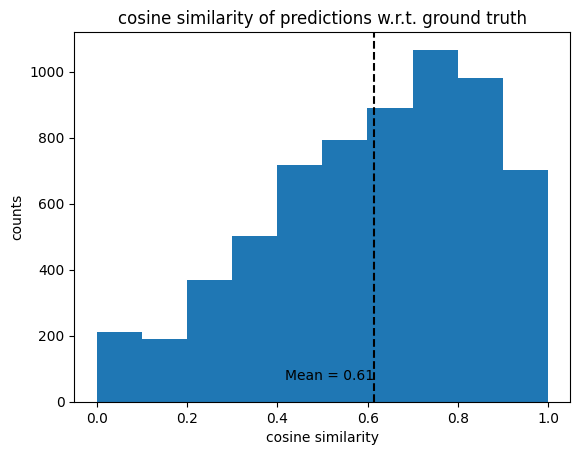

6419


In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.hist(sims, bins=10)
mean = sims.mean()

ax.axvline(mean, linestyle="--", color='black')

# Label next to the mean line, near the bottom
ymin, ymax = ax.get_ylim()
ax.text(
    mean,
    ymin + 0.05 * (ymax - ymin),
    f"Mean = {mean:.2f}",
    color='black',
    va="bottom",
    ha="right",
)
ax.set_xlabel("cosine similarity")
ax.set_ylabel("counts")
ax.set_title("cosine similarity of predictions w.r.t. ground truth")
plt.show()
print(len(sims))

In [13]:
# stratify cosine similarity analysis by split
splits_dp = "/home/luke/fragnnet/data/split/nist20_scaffold/"
test = splits_dp + "test_ids.csv"
train = splits_dp + "train_ids.csv"
val = splits_dp + "val_ids.csv"

def get_mol_ids_from_split(fp):
    df = pd.read_csv(fp)
    return df['mol_id'].to_list()

test_mol_ids = get_mol_ids_from_split(test)
train_mol_ids = get_mol_ids_from_split(train)
val_mol_ids = get_mol_ids_from_split(val)

def get_batch_idxs_by_split(df, split_ids):
    df['in_split'] = df['nist20_mol_id'].apply(
        lambda x: x in split_ids
    )
    filtered = df.loc[df['in_split']]
    return th.Tensor(filtered.index)

test_idx = get_batch_idxs_by_split(mapped_result, test_mol_ids)
train_idx = get_batch_idxs_by_split(mapped_result, train_mol_ids)
val_idx = get_batch_idxs_by_split(mapped_result, val_mol_ids)

In [17]:
print(len(set(test_idx).intersection(set(train_idx))))
print(len(set(test_idx).intersection(set(val_idx))))
print(len(set(val_idx).intersection(set(train_idx))))
print(len(set(train_idx)) + len(set(test_idx)) + len(set(val_idx)))

0
0
0
6077


In [ ]:
def batch_then_sim(df):
    pred_mzs_lst = [
        th.as_tensor(x, dtype=th.float32)
        for x in df["pred_mzs"].to_list()
        ]
    pred_ints_lst = [
        th.as_tensor(x, dtype=th.float32)
        for x in df["pred_ints"].to_list()
    ]
    real_mzs_lst = [
        th.as_tensor(x, dtype=th.float32)
        for x in df["mzs"].to_list()
    ]
    real_ints_lst = [
        th.as_tensor(x, dtype=th.float32)
        for x in df["ints"].to_list()
    ]
    batched_preds = su.batch_func(pred_mzs_lst, pred_ints_lst)
    batched_reals = su.batch_func(real_mzs_lst, real_ints_lst)
    sims = su.calculate_sparse_cosine_similarity(
        true_mzs=batched_reals[0], true_ints=batched_reals[1], true_batch_idxs=batched_reals[2],
        pred_mzs=batched_preds[0], pred_ints=batched_preds[1], pred_batch_idxs=batched_preds[2])
    return sims

def summarize_df(result_df, test_ids, train_ids, val_ids):

    result_df['train'] = result_df['nist20_mol_id'].map(lambda x: x in train_ids)
    result_df['val'] = result_df['nist_20_mol_id'].map(lambda x: x in val_ids)
    result_df['test'] = result_df['nist20_mol_id'].map(lambda x: x in test_ids)

    train = result_df.loc[result_df['train']]
    val = result_df.loc[result_df['val']]
    test = result_df.loc[result_df['test']]

    train_sim = batch_then_sim(train)
    val_sim = batch_then_sim(val)
    test_sim = batch_then_sim(test)

    return {
        'train_sims': train_sim,
        'train_mean': train_sim.mean(),
        'val_sims': val_sim,
        'val_mean': val_sim.mean(),
        'test_sims': test_sim,
        'test_mean': test_sim.mean(),
    }